# 03 — Visualizations and Insights

This notebook turns the main findings from the previous analysis notebooks into a focused set of visualizations. The goal is not to create as many charts as possible, but to communicate the strongest patterns clearly and honestly.

The project has two main layers. The metadata analysis showed strong and interpretable patterns around time controls, rating gaps, and favorite reliability. The engine-evaluation analysis was more mixed: the features were useful to engineer and validate, but broad evaluation-volatility summaries were flatter than expected and came with important limitations.

Because of that, this notebook focuses on a small number of visuals that actually support the project story. Some charts highlight strong findings, while others explain limitations that affected what could and could not be claimed.


In [1]:
import pandas as pd
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns

RAW_DATA_PATH = Path("../data/raw/lichess_200k.csv")

METADATA_DB_PATH = Path("../data/processed/games.db")
EVAL_DB_PATH = Path("../data/processed/eval_features.db")

FIGURES_DIR = Path("../reports/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

metadata_conn = sqlite3.connect(METADATA_DB_PATH)
eval_conn = sqlite3.connect(EVAL_DB_PATH)

def run_metadata_query(query):
    return pd.read_sql_query(query, metadata_conn)

def run_eval_query(query):
    return pd.read_sql_query(query, eval_conn)

sns.set_theme(
    style="whitegrid",
    context="notebook",
    font_scale=1.05
)

plt.rcParams["figure.dpi"] = 120
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

In [2]:
# Helper functions and defining palettes

def save_figure(fig, filename):
    """
    Save a matplotlib figure to the reports/figures folder.
    """
    fig.savefig(
        FIGURES_DIR / filename,
        dpi=300,
        bbox_inches="tight"
    )


def comma_format(x, pos):
    """
    Format axis tick values with comma separators.
    """
    return f"{int(x):,}"


def format_thousands_axis(ax, axis="y"):
    """
    Format large axis values with comma separators.
    """
    formatter = FuncFormatter(comma_format)

    if axis == "y":
        ax.yaxis.set_major_formatter(formatter)
    elif axis == "x":
        ax.xaxis.set_major_formatter(formatter)

def percent_format(x, pos):
    """
    Format axis tick values as percentages.
    """
    return f"{x:.0f}%"


def format_percent_axis(ax, axis="y"):
    """
    Format axis values as percentages.
    """
    formatter = FuncFormatter(percent_format)

    if axis == "y":
        ax.yaxis.set_major_formatter(formatter)
    elif axis == "x":
        ax.xaxis.set_major_formatter(formatter)

MAIN_COLOR = "#4C72B0"
ACCENT_COLOR = "#DD8452"
LIMITATION_COLOR = "#8172B2"
NEUTRAL_COLOR = "#6C757D"


## Visualization Plan

This notebook focuses on six visuals that support the main project story. I don't want to visualize every table from the previous notebooks. Instead, I'm choosing charts that either show a strong finding or explain an important limitation.

The first part focuses on metadata-level insights: how time controls affect game endings, and how rating gap affects favorite reliability. The second part uses the engine-evaluation features more carefully, showing both what they reveal and where they become limited.


## Time Pressure Shapes Bullet Games

The first major finding is that faster time controls change how games end. Bullet games have a much higher time-forfeit rate than the other categories, making time pressure one of the clearest metadata-level patterns in the project.


In [3]:
termination_patterns_category_query = """
WITH termination_by_category AS (
    SELECT
        g.category,
        COUNT(*) AS total_games,
        SUM(CASE
                WHEN g.Termination = 'Normal' THEN 1
                ELSE 0
            END) AS normal_games,
        SUM(CASE
                WHEN g.Termination = 'Time forfeit' THEN 1
                ELSE 0
            END) AS time_forfeit_games
    FROM games AS g
    GROUP BY g.category
)

SELECT
    tbc.category,
    tbc.total_games,
    tbc.normal_games,
    tbc.time_forfeit_games,
    ROUND(tbc.time_forfeit_games * 100.0 / tbc.total_games, 2) AS time_forfeit_rate
FROM termination_by_category AS tbc
ORDER BY time_forfeit_rate DESC;
"""

termination_patterns_category_df = run_metadata_query(termination_patterns_category_query)

termination_patterns_category_df

,category,total_games,normal_games,time_forfeit_games,time_forfeit_rate
0,Bullet,43253,21758,21495,49.70
1,Blitz,86333,67554,18778,21.75
2,Rapid,45216,39235,5973,13.21
3,Classical,25198,22970,2220,8.81


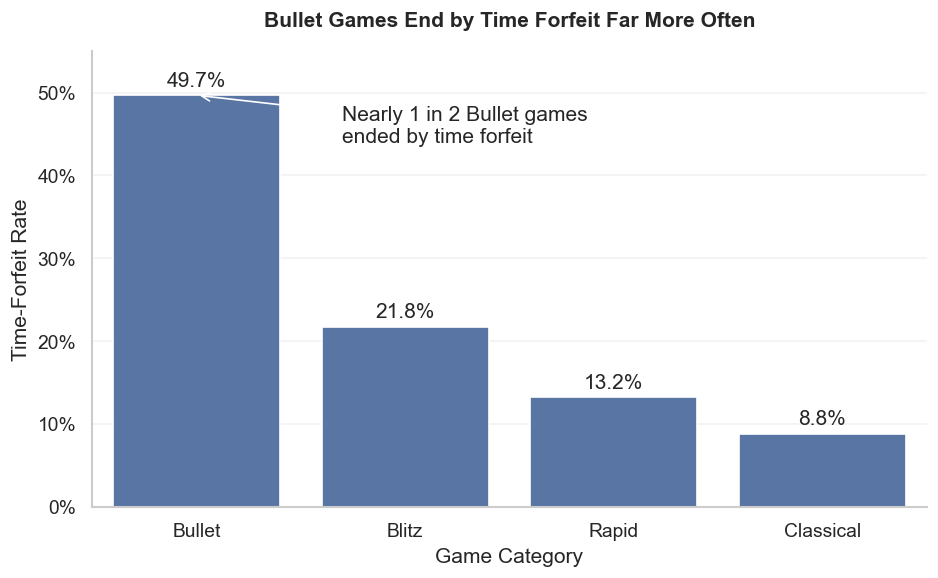

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=termination_patterns_category_df,
    x="category",
    y="time_forfeit_rate",
    color=MAIN_COLOR,
    ax=ax
)

ax.set_title("Bullet Games End by Time Forfeit Far More Often", pad=15, fontweight="bold")
ax.set_xlabel("Game Category")
ax.set_ylabel("Time-Forfeit Rate")

format_percent_axis(ax, axis="y")

ax.set_ylim(0, 55)

ax.grid(axis="y", alpha=0.25)
ax.grid(axis="x", visible=False)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

bullet_rate = termination_patterns_category_df.loc[
    termination_patterns_category_df["category"] == "Bullet",
    "time_forfeit_rate"
][0]

ax.annotate(
    "Nearly 1 in 2 Bullet games\nended by time forfeit",
    xy=(0, bullet_rate),
    xytext=(0.7, 46),
    arrowprops={
        "arrowstyle": "->",
        "linewidth": 1
    },
    ha="left",
    va="center"
)

sns.despine(ax=ax)
plt.tight_layout()

save_figure(fig, "time_forfeit_rate_by_category.png")
plt.show()

Bullet games stand out clearly from the other categories. Nearly half of Bullet games ended by time forfeit, compared with much lower rates in Blitz, Rapid, and Classical games.

This suggests that the faster the time control becomes, the more the clock shapes how games end. However, this does not mean Bullet favors one color over the other; the earlier SQL analysis showed that time-forfeit wins were almost evenly split between White and Black.


## Rating Gap Makes Favorites More Reliable

The next question is whether the rating favorite becomes more reliable as the rating gap increases. Instead of only asking whether favorites usually win, this chart looks at how favorite win rate changes across rating-gap buckets.

This is one of the clearest metadata-level patterns in the project: larger rating gaps are associated with a steadily higher favorite win rate.


In [5]:
rating_gap_outcome_query = """
WITH rating_gap_outcomes AS (
	SELECT
		CASE
			WHEN abs_rating_diff BETWEEN 51 AND 99 THEN '51-99'
			WHEN abs_rating_diff BETWEEN 100 AND 199 THEN '100-199'
			WHEN abs_rating_diff BETWEEN 200 AND 399 THEN '200-399'
			ELSE '400+'
		END AS rating_gap_bucket,
		COUNT(*) AS total_decisive_favorite_games,
		SUM(CASE
				WHEN (g.rating_favorite = 'White favorite' AND g.winner = 'White') 
				OR (g.rating_favorite = 'Black favorite' AND g.winner = 'Black') 
				THEN 1
				ELSE 0
			END) AS favorite_wins,
		SUM(CASE
				WHEN (g.rating_favorite = 'Black favorite' AND g.winner = 'White')
				OR (g.rating_favorite = 'White favorite' AND g.winner = 'Black')
				THEN 1
				ELSE 0
			END) AS upsets
	FROM games AS g
	WHERE g.winner IN ('White', 'Black')
		AND g.rating_favorite IN ('White favorite', 'Black favorite')
	GROUP BY rating_gap_bucket
	
)

SELECT
	rgo.rating_gap_bucket,
	rgo.total_decisive_favorite_games,
	rgo.favorite_wins,
	rgo.upsets,
	ROUND(rgo.favorite_wins * 100.0 / rgo.total_decisive_favorite_games, 2) AS favorite_win_rate,
	ROUND(rgo.upsets * 100.0 / rgo.total_decisive_favorite_games, 2) AS upset_rate
FROM rating_gap_outcomes AS rgo
ORDER BY favorite_win_rate DESC;
"""

rating_gap_outcome_df = run_metadata_query(rating_gap_outcome_query)

rating_gap_outcome_df


,rating_gap_bucket,total_decisive_favorite_games,favorite_wins,upsets,favorite_win_rate,upset_rate
0,400+,4202,3313,889,78.84,21.16
1,200-399,13912,9782,4130,70.31,29.69
2,100-199,29600,18291,11309,61.79,38.21
3,51-99,40445,22619,17826,55.93,44.07


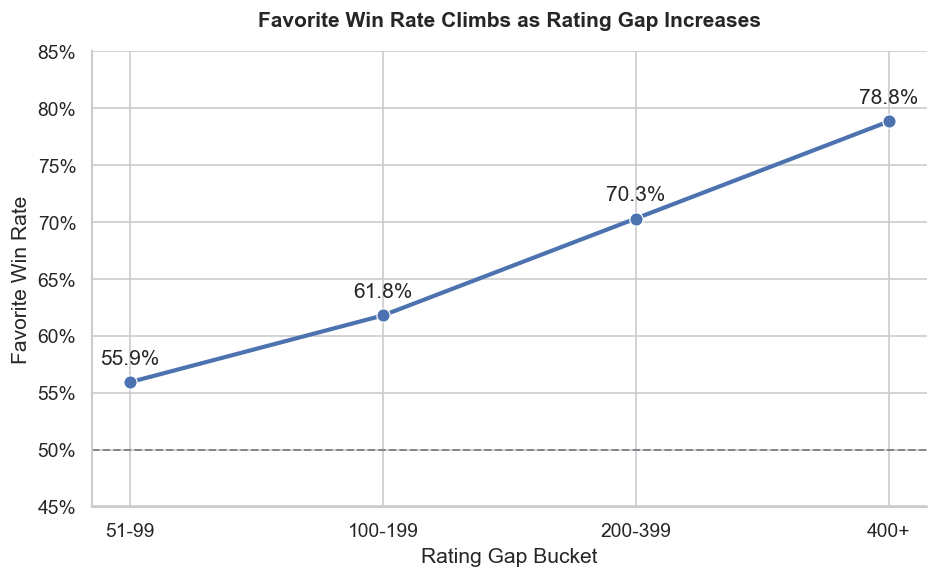

In [6]:
rating_gap_order = ["51-99", "100-199", "200-399", "400+"]

rating_gap_outcome_df["rating_gap_bucket"] = pd.Categorical(
    rating_gap_outcome_df["rating_gap_bucket"],
    categories=rating_gap_order,
    ordered=True
)

rating_gap_outcome_df = rating_gap_outcome_df.sort_values("rating_gap_bucket")

fig, ax = plt.subplots(figsize=(8, 5))

sns.lineplot(
    data=rating_gap_outcome_df,
    x="rating_gap_bucket",
    y="favorite_win_rate",
    color=MAIN_COLOR,
    marker="o",
    linewidth=2.5,
    markersize=8,
    ax=ax
)

ax.axhline(
    50,
    color=NEUTRAL_COLOR,
    linestyle="--",
    linewidth=1.2,
    alpha=0.8
)

for row_index, row in rating_gap_outcome_df.iterrows():
    ax.text(
        row["rating_gap_bucket"],
        row["favorite_win_rate"] + 1.2,
        f"{row['favorite_win_rate']:.1f}%",
        ha="center",
        va="bottom"
    )

ax.set_title("Favorite Win Rate Climbs as Rating Gap Increases", pad=15, fontweight="bold")
ax.set_xlabel("Rating Gap Bucket")
ax.set_ylabel("Favorite Win Rate")

ax.set_ylim(45, 85)
format_percent_axis(ax, axis="y")

sns.despine(ax=ax)
plt.tight_layout()

save_figure(fig, "favorite_win_rate_by_rating_gap.png")
plt.show()


The favorite win rate rises steadily as the rating gap increases. In close favorite matchups, the favorite wins only slightly more than half the time, but once the rating gap reaches 400+ points, the favorite wins almost 79% of decisive games.

This makes rating gap one of the clearest predictors in the project. Game category affects how games end, especially through time forfeits, but rating gap more directly captures the strength difference between the two players.


## Rating Gap Remains Important Across Game Categories

The previous chart showed that favorite win rate increases as the rating gap gets larger. This heatmap checks whether that pattern still appears when game category is included.

This matters because category affects the environment of the game, especially through time pressure. If rating gap is still clearly related to favorite reliability across Bullet, Blitz, Rapid, and Classical games, then rating gap is a stronger and more consistent metadata signal than category alone.


In [7]:
rating_gap_category_query = """
WITH category_rating_gap_outcomes AS (
    SELECT
        g.category,
        CASE
            WHEN abs_rating_diff BETWEEN 51 AND 99 THEN '51-99'
            WHEN abs_rating_diff BETWEEN 100 AND 199 THEN '100-199'
            WHEN abs_rating_diff BETWEEN 200 AND 399 THEN '200-399'
            ELSE '400+'
        END AS rating_gap_bucket,
        CASE
            WHEN abs_rating_diff BETWEEN 51 AND 99 THEN 1
            WHEN abs_rating_diff BETWEEN 100 AND 199 THEN 2
            WHEN abs_rating_diff BETWEEN 200 AND 399 THEN 3
            ELSE 4
        END AS bucket_order,
        COUNT(*) AS total_decisive_favorite_games,
        SUM(CASE
                WHEN (g.rating_favorite = 'White favorite' AND g.winner = 'White') 
                  OR (g.rating_favorite = 'Black favorite' AND g.winner = 'Black') 
                THEN 1
                ELSE 0
            END) AS favorite_wins
    FROM games AS g
    WHERE g.winner IN ('White', 'Black')
        AND g.rating_favorite IN ('White favorite', 'Black favorite')
    GROUP BY
        g.category,
        rating_gap_bucket,
        bucket_order
)

SELECT
    category,
    rating_gap_bucket,
    bucket_order,
    total_decisive_favorite_games,
    favorite_wins,
    ROUND(favorite_wins * 100.0 / total_decisive_favorite_games, 2) AS favorite_win_rate
FROM category_rating_gap_outcomes
ORDER BY
    category,
    bucket_order;
"""

rating_gap_category_df = run_metadata_query(rating_gap_category_query)

rating_gap_category_df


,category,rating_gap_bucket,bucket_order,total_decisive_favorite_games,favorite_wins,favorite_win_rate
0,Blitz,51-99,1,17074,9402,55.07
1,Blitz,100-199,2,11934,7242,60.68
2,Blitz,200-399,3,5317,3645,68.55
3,Blitz,400+,4,1554,1181,76.00
4,Bullet,51-99,1,8982,5137,57.19
5,Bullet,100-199,2,6933,4292,61.91
6,Bullet,200-399,3,3551,2529,71.22
7,Bullet,400+,4,1324,1088,82.18
8,Classical,51-99,1,5603,3177,56.70
9,Classical,100-199,2,4058,2590,63.82


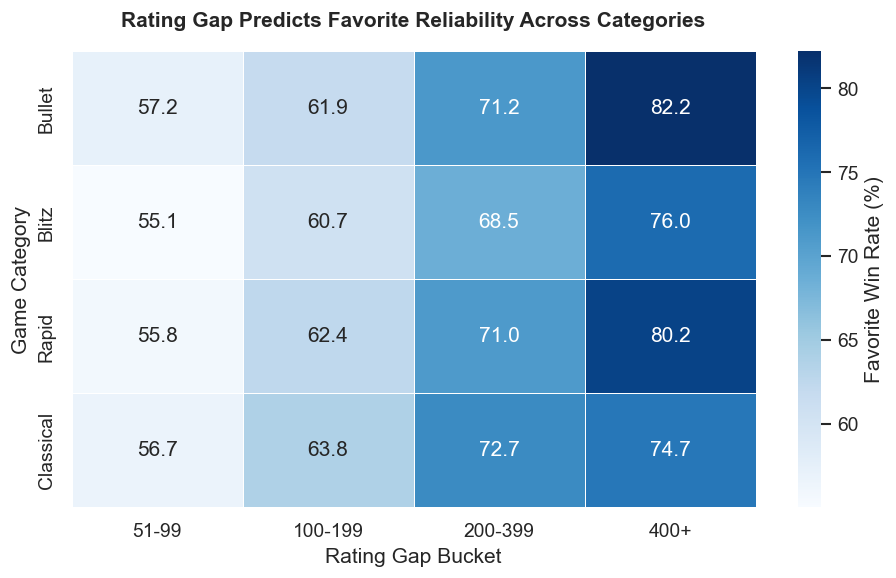

In [8]:
category_order = ["Bullet", "Blitz", "Rapid", "Classical"]
rating_gap_order = ["51-99", "100-199", "200-399", "400+"]

heatmap_df = (
    rating_gap_category_df
    .pivot(
        index="category",
        columns="rating_gap_bucket",
        values="favorite_win_rate"
    )
    .reindex(index=category_order, columns=rating_gap_order)
)

fig, ax = plt.subplots(figsize=(8, 5))

sns.heatmap(
    data=heatmap_df,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    linewidths=0.5,
    cbar_kws={"label": "Favorite Win Rate (%)"},
    ax=ax
)

ax.set_title(
    "Rating Gap Predicts Favorite Reliability Across Categories",
    pad=15,
    fontweight="bold"
)
ax.set_xlabel("Rating Gap Bucket")
ax.set_ylabel("Game Category")

plt.tight_layout()

save_figure(fig, "favorite_win_rate_heatmap_by_category_and_rating_gap.png")
plt.show()


The heatmap shows the same general pattern across categories: favorite win rate increases as the rating gap gets larger. Category still matters for how games end, but the rating-gap gradient is visible across the different time controls.

This supports the main metadata conclusion from the SQL notebook: rating gap is the clearest signal for favorite reliability. Time control changes the game environment, but player-strength difference is more directly connected to who wins.


## Evaluation Swings Are Surprisingly Similar Across Categories

After the metadata charts, I wanted to see whether faster games also had more unstable engine evaluations. Since Bullet games are much more affected by time pressure, it would be reasonable to expect their evaluation swings to be much larger.

Instead, the average maximum evaluation swing is almost identical across categories. This does not mean every game behaves the same, but it suggests that broad average eval-swing features are not enough to explain the differences between time controls.


In [9]:
avg_eval_swing_by_category_query = """
SELECT
    ef.category,
    COUNT(*) AS total_games,
    ROUND(AVG(ef.max_eval_swing), 2) AS avg_max_eval_swing
FROM eval_features AS ef
WHERE ef.max_eval_swing IS NOT NULL
GROUP BY ef.category
ORDER BY avg_max_eval_swing DESC;
"""

avg_eval_swing_by_category_df = run_eval_query(avg_eval_swing_by_category_query)

avg_eval_swing_by_category_df


,Category,total_games,avg_max_eval_swing
0,Blitz,86332,16.17
1,Rapid,45216,16.15
2,Bullet,43253,16.13
3,Classical,25198,16.09


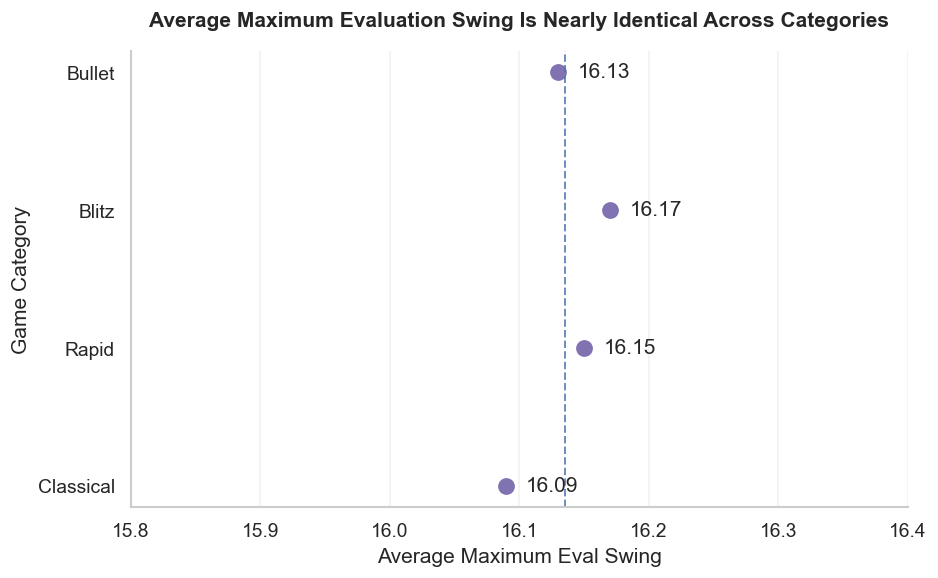

In [10]:
category_order = ["Bullet", "Blitz", "Rapid", "Classical"]

avg_eval_swing_by_category_df["Category"] = pd.Categorical(
    avg_eval_swing_by_category_df["Category"],
    categories=category_order,
    ordered=True
)

avg_eval_swing_by_category_df = avg_eval_swing_by_category_df.sort_values("Category")

mean_swing = avg_eval_swing_by_category_df["avg_max_eval_swing"].mean()

fig, ax = plt.subplots(figsize=(8, 5))

sns.scatterplot(
    data=avg_eval_swing_by_category_df,
    x="avg_max_eval_swing",
    y="Category",
    color=LIMITATION_COLOR,
    s=120,
    ax=ax
)

ax.axvline(
    mean_swing,
    linestyle="--",
    linewidth=1.2,
    alpha=0.8
)

for row_index, row in avg_eval_swing_by_category_df.iterrows():
    ax.text(
        row["avg_max_eval_swing"] + 0.015,
        row["Category"],
        f"{row['avg_max_eval_swing']:.2f}",
        ha="left",
        va="center"
    )

ax.set_title("Average Maximum Evaluation Swing Is Nearly Identical Across Categories", pad=15, fontweight="bold")
ax.set_xlabel("Average Maximum Eval Swing")
ax.set_ylabel("Game Category")

ax.set_xlim(15.8, 16.4)

ax.grid(axis="x", alpha=0.25)
ax.grid(axis="y", visible=False)

sns.despine(ax=ax)
plt.tight_layout()

save_figure(fig, "avg_max_eval_swing_by_category.png")
plt.show()

The average maximum evaluation swing is almost the same across all four categories. This is surprising because the metadata analysis showed that game category strongly affects how games end, especially through time forfeits.

This suggests that broad average evaluation-swing features are too blunt to explain the differences between time controls. The categories behave very differently in terms of time pressure, but their average maximum evaluation swings are nearly identical.


## Final Eval Sign Does Not Clearly Separate Termination Types

After checking broad evaluation swings, I also wanted to test whether the final available evaluation sign could be interpreted as a simple winner advantage. If the sign clearly represented White or Black advantage, then White wins and Black wins should show very different final-evaluation sign patterns.

Instead, the sign split is almost balanced. This makes the raw final evaluation sign unsafe for claims like “the winner was ahead” or “the loser was behind.”


In [11]:
final_eval_sign_split_query = """
WITH final_eval_sign_split AS (
    SELECT
        Termination,
        COUNT(*) AS total_games,
        SUM(CASE
                WHEN final_available_eval < -0.5 THEN 1
                ELSE 0
            END) AS negative_eval_games,
        SUM(CASE
                WHEN final_available_eval BETWEEN -0.5 AND 0.5 THEN 1
                ELSE 0
            END) AS roughly_equal_games,
        SUM(CASE
                WHEN final_available_eval > 0.5 THEN 1
                ELSE 0
            END) AS positive_eval_games
    FROM eval_features
    WHERE Termination IN ('Normal', 'Time forfeit')
        AND final_available_eval IS NOT NULL
    GROUP BY Termination
)

SELECT
    Termination,
    total_games,
    negative_eval_games,
    roughly_equal_games,
    positive_eval_games,
    ROUND(negative_eval_games * 100.0 / total_games, 2) AS negative_eval_rate,
    ROUND(roughly_equal_games * 100.0 / total_games, 2) AS roughly_equal_rate,
    ROUND(positive_eval_games * 100.0 / total_games, 2) AS positive_eval_rate
FROM final_eval_sign_split
ORDER BY
    CASE Termination
        WHEN 'Normal' THEN 1
        WHEN 'Time forfeit' THEN 2
    END;
"""

final_eval_sign_split_df = run_eval_query(final_eval_sign_split_query)

final_eval_sign_split_df

,Termination,total_games,negative_eval_games,roughly_equal_games,positive_eval_games,negative_eval_rate,roughly_equal_rate,positive_eval_rate
0,Normal,151516,68689,10216,72611,45.33,6.74,47.92
1,Time forfeit,48466,21870,3238,23358,45.12,6.68,48.19


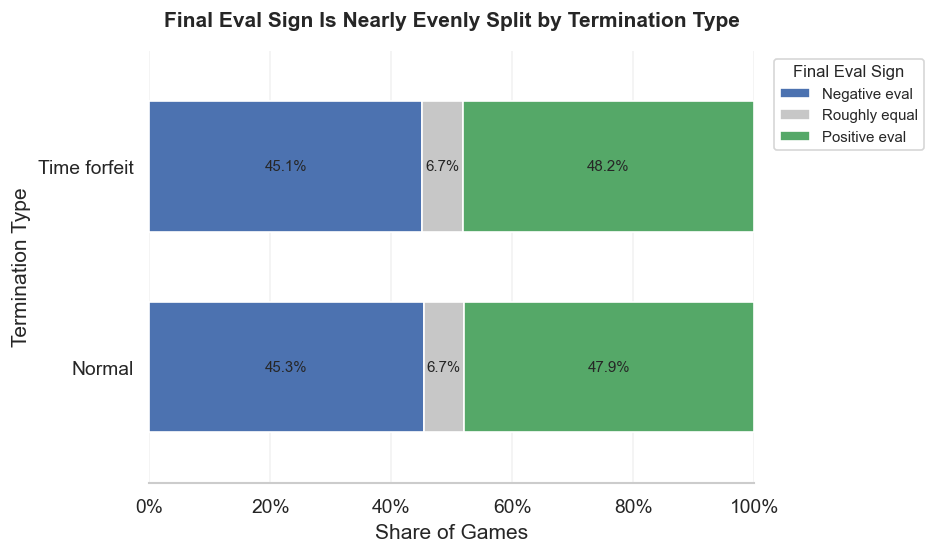

In [12]:
SIGN_COLORS = ["#4C72B0", "#C7C7C7", "#55A868"]
plot_df = final_eval_sign_split_df.set_index("Termination")[
    ["negative_eval_rate", "roughly_equal_rate", "positive_eval_rate"]
]

plot_df = plot_df.rename(
    columns={
        "negative_eval_rate": "Negative eval",
        "roughly_equal_rate": "Roughly equal",
        "positive_eval_rate": "Positive eval"
    }
)

fig, ax = plt.subplots(figsize=(8, 4.8))

plot_df.plot(
    kind="barh",
    stacked=True,
    color=SIGN_COLORS,
    ax=ax,
    width=0.65
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        label_type="center",
        fontsize=9
    )

ax.set_title("Final Eval Sign Is Nearly Evenly Split by Termination Type", pad=15, fontweight="bold")
ax.set_xlabel("Share of Games")
ax.set_ylabel("Termination Type")

ax.set_xlim(0, 100)
format_percent_axis(ax, axis="x")

ax.grid(axis="x", alpha=0.25)
ax.grid(axis="y", visible=False)

ax.legend(
    title="Final Eval Sign",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=9,
    title_fontsize=10
)

sns.despine(left=True)
plt.tight_layout()

save_figure(fig, "final_eval_sign_split_by_termination.png")
plt.show()

The final evaluation sign is almost evenly split for both normal and time-forfeit games. In both termination types, the share of negative and positive final evaluations is very similar, with only a small percentage of games ending near equality.

This is an important limitation. If the raw final evaluation sign clearly represented winner advantage, the split would not look this balanced. Because of this, I avoid claims such as “the winner was ahead” or “the loser was behind” based only on `final_available_eval`.


## Later Evaluation Columns Become Mostly Missing

The final engine-evaluation limitation is availability. The raw dataset contains many `Eval_ply_*` columns, but later ply columns are only populated for games that lasted long enough and had an evaluation recorded at that point.

This matters because late-game analysis would rely on a much smaller and less representative subset of games. Before making deeper claims about late-game evaluation patterns, I need to understand how quickly evaluation coverage drops across ply numbers.


In [13]:
all_cols = pd.read_csv(RAW_DATA_PATH, nrows=0).columns

eval_cols = []
for col in all_cols:
    if col.startswith("Eval_ply_"):
        eval_cols.append(col)

eval_cols = sorted(
    eval_cols,
    key=lambda col: int(col.replace("Eval_ply_", ""))
)

eval_only_df = pd.read_csv(
    RAW_DATA_PATH,
    usecols=eval_cols,
    dtype="string"
)

missing_rows = []

total_games = len(eval_only_df)

for col in eval_cols:
    ply_number = int(col.replace("Eval_ply_", ""))
    missing_count = eval_only_df[col].isna().sum()
    available_count = total_games - missing_count
    missing_share_percent = missing_count * 100.0 / total_games
    available_share_percent = available_count * 100.0 / total_games

    missing_rows.append(
        {
            "ply": ply_number,
            "eval_column": col,
            "available_count": available_count,
            "missing_count": missing_count,
            "available_share_percent": available_share_percent,
            "missing_share_percent": missing_share_percent
        }
    )

eval_missingness_by_ply_df = pd.DataFrame(missing_rows)

eval_missingness_by_ply_df.head()

,ply,eval_column,available_count,missing_count,available_share_percent,missing_share_percent
0,1,Eval_ply_1,200000,0,100.00,0.00
1,2,Eval_ply_2,200000,0,100.00,0.00
2,3,Eval_ply_3,200000,0,100.00,0.00
3,4,Eval_ply_4,200000,0,100.00,0.00
4,5,Eval_ply_5,199997,3,100.00,0.00


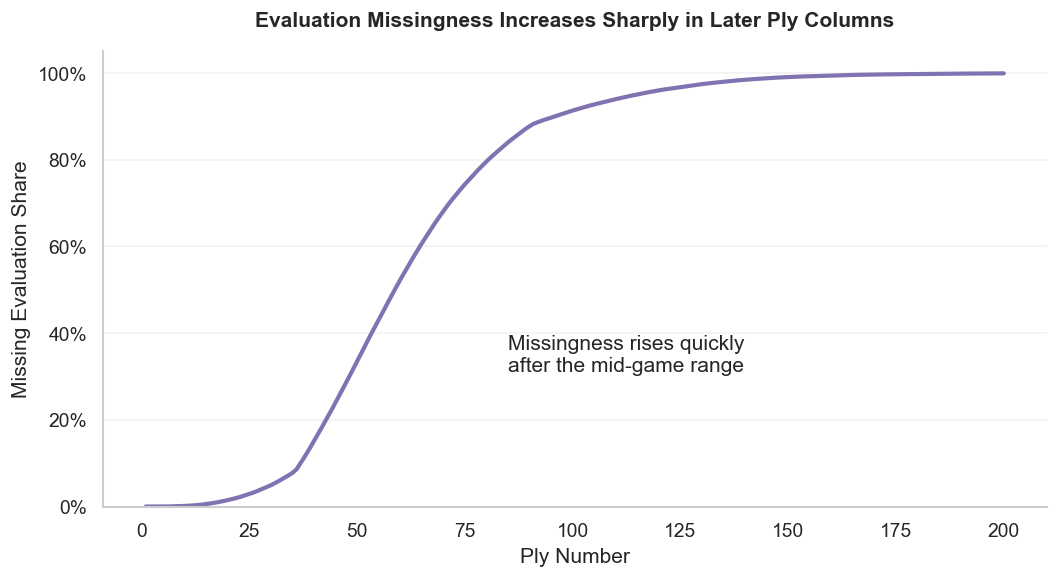

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.lineplot(
    data=eval_missingness_by_ply_df,
    x="ply",
    y="missing_share_percent",
    linewidth=2.5,
    color=LIMITATION_COLOR,
    ax=ax
)

ax.set_title("Evaluation Missingness Increases Sharply in Later Ply Columns", pad=15, fontweight="bold")
ax.set_xlabel("Ply Number")
ax.set_ylabel("Missing Evaluation Share")

ax.grid(axis="y", alpha=0.25)
ax.grid(axis="x", visible=False)

ax.set_ylim(0, 105)
format_percent_axis(ax, axis="y")

ax.annotate(
    "Missingness rises quickly\nafter the mid-game range",
    xy=(60, 45),
    xytext=(85, 35),
    arrowprops={
        "arrowstyle": "->",
        "linewidth": 1
    },
    ha="left",
    va="center"
)

sns.despine(ax=ax)
plt.tight_layout()

save_figure(fig, "eval_missingness_by_ply.png")
plt.show()


Evaluation coverage drops sharply as ply number increases. Early evaluation columns are available for almost every game, but later columns become mostly missing because many games end before reaching those ply numbers.

This limits how far I can push late-game engine-evaluation analysis in this project. A deeper version would need a move-level dataset or a more careful sampling strategy, so that late-game conclusions are not based only on the smaller subset of games that lasted long enough.


## Final Summary

The clearest findings in this project came from the metadata analysis. Bullet games were much more affected by time pressure, with nearly half ending by time forfeit. Rating gap was also the strongest signal for favorite reliability: as the gap increased, the favorite win rate climbed steadily across the rating-gap buckets and remained visible across game categories.

The engine-evaluation features were useful, but in a different way than expected. Broad evaluation-swing averages were almost identical across categories, and the final evaluation sign did not support safe winner-direction claims. The missingness-by-ply chart also showed that later evaluation columns become mostly unavailable, which limits how far late-game analysis can be pushed without a more detailed move-level structure.

Overall, the main lesson is that feature engineering is hypothesis testing, not decoration. Some features produced strong insights, while others mainly revealed limitations. That still made the project stronger, because it helped separate what the data clearly supports from what would require deeper validation.
